# Macula Transfer Learning Object Detection

The notebook is divided into 7 sections:
1. Installing Supergradients
2. Dataset definition
3. Training
4. Predicting


## 1. Installing Supergradients

In [1]:
! pip install -qq super_gradients==3.7.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 33.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.5/684.5 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.6/408.6 kB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 69.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 65.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to bui

# 2. Dataset definition


In [ ]:
from super_gradients.training import Trainer
from super_gradients.training import dataloaders
from super_gradients.training.dataloaders.dataloaders import (
    coco_detection_yolo_format_train, 
    coco_detection_yolo_format_val
)
from super_gradients.training import models
from super_gradients.training.losses import PPYoloELoss
from super_gradients.training.metrics import (
    DetectionMetrics_050,
    DetectionMetrics_050_095
)
from super_gradients.training.models.detection_models.pp_yolo_e import PPYoloEPostPredictionCallback

The console stream is logged into C:\Users\hongb\sg_logs\console.log


d:\anaconda3\envs\yolonas\lib\site-packages\super_gradients\common\environment\cfg_utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2025-11-29 20:10:02] INFO - crash_tips_setup.py - Crash tips is enabled. You can set your environment variable to CRASH_HANDLER=FALSE to disable it
W1129 20:10:02.833077 44272 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


[WARNING]No module named 'pycocotools'


[2025-11-29 20:10:11] WARNING - env_sanity_check.py - Failed to verify operating system: Deci officially supports only Linux kernels. Some features may not work as expected.


d:\anaconda3\envs\yolonas\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting up the training data, make sure the images and labels in COCO format.

In [ ]:
from super_gradients.training.dataloaders.dataloaders import (
    coco_detection_yolo_format_train, 
    coco_detection_yolo_format_val
)

# Global parameters.
EPOCHS = 50
BATCH_SIZE = 8
WORKERS = 4

ROOT_DIR = './datasets/eyes'
train_imgs_dir = 'images/train'
train_labels_dir = 'labels/train'
val_imgs_dir = 'images/val'
val_labels_dir = 'labels/val'
classes = ['macula','optic-disc']
 
dataset_params = {
    'data_dir':ROOT_DIR,
    'train_images_dir':train_imgs_dir,
    'train_labels_dir':train_labels_dir,
    'val_images_dir':val_imgs_dir,
    'val_labels_dir':val_labels_dir,
    'classes':classes 
}

In [3]:
train_data = coco_detection_yolo_format_train(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['train_images_dir'],
        'labels_dir': dataset_params['train_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size':BATCH_SIZE,
        'num_workers':WORKERS
    }
)
 
val_data = coco_detection_yolo_format_val(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['val_images_dir'],
        'labels_dir': dataset_params['val_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size':BATCH_SIZE,
        'num_workers':WORKERS
    }
)

[2025-11-29 20:10:38] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 500/500 [00:03<00:00, 148.33it/s]
[2025-11-29 20:10:41] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations:  55%|█████▌    | 55/100 [00:00<00:00, 267.55it/s]

Indexing dataset annotations: 100%|██████████| 100/100 [00:00<00:00, 267.00it/s]


Taking a look at some of the transformations

In [4]:
	
train_data.dataset.transforms

In [5]:
# Removing MixUp as it made the performance of the model worse
train_data.dataset.transforms.pop(2)

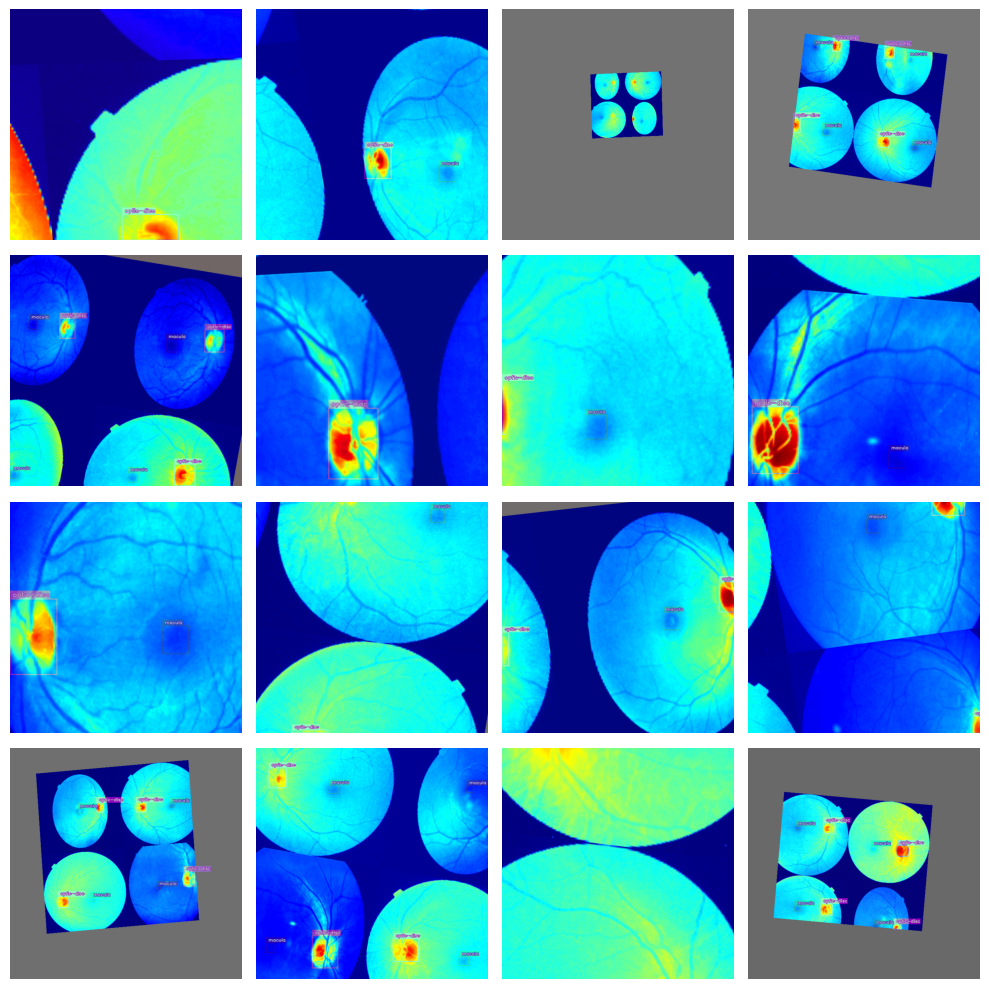

In [6]:
# visualizing the transforms
train_data.dataset.plot(plot_transformed_data=True)

## 3. Training

Setting up hyperparameters and begin training. This took about 90 mins on a Nvidia 4070 ti consumer GPU.

In [7]:
train_params = {
    'silent_mode': False,
    "average_best_models":True,
    "warmup_mode": "linear_epoch_step",
    "warmup_initial_lr": 1e-6,
    "lr_warmup_epochs": 3,
    "initial_lr": 5e-4,
    "lr_mode": "cosine",
    "cosine_final_lr_ratio": 0.1,
    "optimizer": "Adam",
    "optimizer_params": {"weight_decay": 0.0001},
    "zero_weight_decay_on_bias_and_bn": True,
    "ema": True,
    "ema_params": {"decay": 0.9, "decay_type": "threshold"},
    "max_epochs": EPOCHS,
    "mixed_precision": True,
    "loss": PPYoloELoss(
        use_static_assigner=False,
        num_classes=len(dataset_params['classes']),
        reg_max=16
    ),
    "valid_metrics_list": [
        DetectionMetrics_050(
            score_thres=0.1,
            top_k_predictions=300,
            num_cls=len(dataset_params['classes']),
            normalize_targets=True,
            post_prediction_callback=PPYoloEPostPredictionCallback(
                score_threshold=0.01,
                nms_top_k=1000,
                max_predictions=300,
                nms_threshold=0.7
            )
        ),
        DetectionMetrics_050_095(
            score_thres=0.1,
            top_k_predictions=300,
            num_cls=len(dataset_params['classes']),
            normalize_targets=True,
            post_prediction_callback=PPYoloEPostPredictionCallback(
                score_threshold=0.01,
                nms_top_k=1000,
                max_predictions=300,
                nms_threshold=0.7
            )
        )
    ],
    "metric_to_watch": 'mAP@0.50:0.95'
}

In [8]:
models_to_train = [
    'yolo_nas_m'
]
 
CHECKPOINT_DIR = 'checkpoints'
 
for model_to_train in models_to_train:
    trainer = Trainer(
        experiment_name=model_to_train, 
        ckpt_root_dir=CHECKPOINT_DIR
    )
 
    model = models.get(
        model_to_train, 
        num_classes=len(dataset_params['classes']), 
        pretrained_weights="coco"
    )
 
    trainer.train(
        model=model, 
        training_params=train_params, 
        train_loader=train_data, 
        valid_loader=val_data
    )

[2025-11-29 20:12:06] WARNING - checkpoint_utils.py - :warning: The pre-trained models provided by SuperGradients may have their own licenses or terms and conditions derived from the dataset used for pre-training.
 It is your responsibility to determine whether you have permission to use the models for your use case.
 The model you have requested was pre-trained on the coco dataset, published under the following terms: https://cocodataset.org/#termsofuse
[2025-11-29 20:12:06] INFO - checkpoint_utils.py - License Notification: YOLO-NAS pre-trained weights are subjected to the specific license terms and conditions detailed in 
https://github.com/Deci-AI/super-gradients/blob/master/LICENSE.YOLONAS.md
By downloading the pre-trained weight files you agree to comply with these terms.
[2025-11-29 20:12:06] INFO - checkpoint_utils.py - Successfully loaded pretrained weights for architecture yolo_nas_m
[2025-11-29 20:12:07] INFO - sg_trainer.py - Starting a new run with `run_id=RUN_20251129_201

The console stream is now moved to checkpoints\yolo_nas_m\RUN_20251129_201207_268938/console_Nov29_20_12_07.txt


d:\anaconda3\envs\yolonas\lib\site-packages\super_gradients\common\registry\registry.py:72: DeprecationWarning: Object name `linear_epoch_step` is now deprecated. Please replace it with `LinearEpochLRWarmup`.
  warnings.warn(f"Object name `{name}` is now deprecated. Please replace it with `{deprecated_names[name]}`.", DeprecationWarning)
d:\anaconda3\envs\yolonas\lib\site-packages\super_gradients\training\utils\optimizer_utils.py:108: DeprecationWarning: initialize_param_groups and update_param_groups usages are deprecated since 3.4.0, will be removed in 3.5.0 and have no effect. 
 Assign different learning rates by passing a mapping of layer name prefixes to lr values through initial_lr training hyperparameter (i.e initial_lr={'backbone': 0.01, 'default':0.1})
  warnings.warn(
d:\anaconda3\envs\yolonas\lib\site-packages\super_gradients\training\sg_trainer\sg_trainer.py:1753: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', arg

SUMMARY OF EPOCH 0
├── Train
│   ├── Ppyoloeloss/loss_cls = 2.4359
│   ├── Ppyoloeloss/loss_iou = 0.7358
│   ├── Ppyoloeloss/loss_dfl = 0.649
│   └── Ppyoloeloss/loss = 3.8207
└── Validation
    ├── Ppyoloeloss/loss_cls = 2.3416
    ├── Ppyoloeloss/loss_iou = 0.8281
    ├── Ppyoloeloss/loss_dfl = 0.8404
    ├── Ppyoloeloss/loss = 4.0101
    ├── Precision@0.50 = 0.0
    ├── Recall@0.50 = 0.0
    ├── Map@0.50 = 0.0012
    ├── F1@0.50 = 0.0
    ├── Best_score_threshold = 0.02
    ├── Precision@0.50:0.95 = 0.0
    ├── Recall@0.50:0.95 = 0.0
    ├── Map@0.50:0.95 = 0.0003
    └── F1@0.50:0.95 = 0.0



Validating epoch 1: 100%|██████████| 13/13 [00:29<00:00,  2.26s/it]
[2025-11-29 20:15:35] INFO - base_sg_logger.py - Checkpoint saved in checkpoints\yolo_nas_m\RUN_20251129_201207_268938\ckpt_best.pth
[2025-11-29 20:15:35] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.30693888664245605


...

SUMMARY OF EPOCH 48
├── Train
│   ├── Ppyoloeloss/loss_cls = 0.6674
│   │   ├── Epoch N-1      = 0.6835 (↘ -0.0162)
│   │   └── Best until now = 0.6674 (↘ -0.0)
│   ├── Ppyoloeloss/loss_iou = 0.4397
│   │   ├── Epoch N-1      = 0.4371 (↗ 0.0027)
│   │   └── Best until now = 0.4344 (↗ 0.0053)
│   ├── Ppyoloeloss/loss_dfl = 0.4199
│   │   ├── Epoch N-1      = 0.424  (↘ -0.0042)
│   │   └── Best until now = 0.403  (↗ 0.0169)
│   └── Ppyoloeloss/loss = 1.5269
│       ├── Epoch N-1      = 1.5446 (↘ -0.0177)
│       └── Best until now = 1.5048 (↗ 0.0221)
└── Validation
    ├── Ppyoloeloss/loss_cls = 0.71
    │   ├── Epoch N-1      = 0.7183 (↘ -0.0082)
    │   └── Best until now = 0.6994 (↗ 0.0106)
    ├── Ppyoloeloss/loss_iou = 0.5201
    │   ├── Epoch N-1      = 0.5316 (↘ -0.0115)
    │   └── Best until now = 0.5067 (↗ 0.0134)
    ├── Ppyoloeloss/loss_dfl = 0.4698
    │   ├── Epoch N-1      = 0.4825 (↘ -0.0127)
    │   └── Best until now = 0.4673 (↗ 0.0025)
    ├── Ppyoloeloss/loss = 1.6999

Validating epoch 49: 100%|██████████| 13/13 [00:26<00:00,  2.05s/it]
[2025-11-29 21:31:27] INFO - base_sg_logger.py - Checkpoint saved in checkpoints\yolo_nas_m\RUN_20251129_201207_268938\ckpt_best.pth
[2025-11-29 21:31:27] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.5269508957862854


SUMMARY OF EPOCH 49
├── Train
│   ├── Ppyoloeloss/loss_cls = 0.6833
│   │   ├── Epoch N-1      = 0.6674 (↗ 0.016)
│   │   └── Best until now = 0.6674 (↗ 0.016)
│   ├── Ppyoloeloss/loss_iou = 0.4392
│   │   ├── Epoch N-1      = 0.4397 (↘ -0.0005)
│   │   └── Best until now = 0.4344 (↗ 0.0048)
│   ├── Ppyoloeloss/loss_dfl = 0.4188
│   │   ├── Epoch N-1      = 0.4199 (↘ -0.001)
│   │   └── Best until now = 0.403  (↗ 0.0159)
│   └── Ppyoloeloss/loss = 1.5414
│       ├── Epoch N-1      = 1.5269 (↗ 0.0145)
│       └── Best until now = 1.5048 (↗ 0.0366)
└── Validation
    ├── Ppyoloeloss/loss_cls = 0.7093
    │   ├── Epoch N-1      = 0.71   (↘ -0.0007)
    │   └── Best until now = 0.6994 (↗ 0.0099)
    ├── Ppyoloeloss/loss_iou = 0.5141
    │   ├── Epoch N-1      = 0.5201 (↘ -0.006)
    │   └── Best until now = 0.5067 (↗ 0.0074)
    ├── Ppyoloeloss/loss_dfl = 0.4674
    │   ├── Epoch N-1      = 0.4698 (↘ -0.0024)
    │   └── Best until now = 0.4673 (↗ 1e-04)
    ├── Ppyoloeloss/loss = 1.6908
 

[2025-11-29 21:31:58] INFO - sg_trainer.py - RUNNING ADDITIONAL TEST ON THE AVERAGED MODEL...
d:\anaconda3\envs\yolonas\lib\site-packages\super_gradients\training\utils\checkpoint_utils.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issu

[2025-11-29 21:32:25] INFO - base_sg_logger.py - [CLEANUP] - Successfully stopped system monitoring process


## 4. Predicting

Testing if our trained model works, ideally this is done on never before seen image but I just did it on an validation image to show that it works without error since we're low on labeled images.

[2025-11-26 14:05:33] INFO - pipelines.py - Fusing some of the model's layers. If this takes too much memory, you can deactivate it by setting `fuse_model=False`


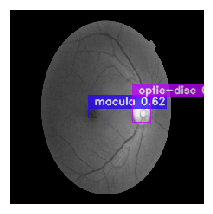

In [11]:
prediction = model.predict('./datasets/eyes/images/val/fc7dd154-5db895d3f1fc.png')
prediction.show()